# RBC demo: clone PNC FreeSurfer data, download 100 pass-QC subjects, and visualize measures on Schaefer-400 atlas

This notebook is a compact demo to get started with **ReproBrainChart (RBC)**.

RBC has a [website](https://reprobrainchart.github.io) with information on the dataset and guielines on how to access and use the data. In addition, the paper accompaniying the data is available at [Shafiei et al., 2025, Neuron](https://doi.org/10.1016/j.neuron.2025.08.026).

It does five things in one place:

1. clones the **PNC_FreeSurfer** DataLad repository,
2. checks out the **`complete-pass-0.1`** branch to clone the data with "Pass" quality control,
3. downloads the files needed for **100 pass-QC subjects**,
4. plots **Schaefer-400 cortical thickness** and **gray matter volume** on the fsaverage5 surface for one subject and for the group mean (across the 100 indiviudals),
5. makes a scatter plot of **mean cortical thickness vs age**.

The plotting is intentionally simple:
- atlas = **`Schaefer2018_400Parcels_7Networks_order`**
- cortical thickness measure = **`ThickAvg`**
- gray matter volume measure = **`GrayVol`**


In [1]:
# Optional setup cell.
# This installs the Python packages used later in the notebook.
# It is commented out so the notebook does not reinstall packages every time.
# Uncomment if needed.

# %pip install pandas numpy matplotlib nilearn nibabel datalad netneurotools


In [2]:
# Import the Python tools used throughout the demo.
# These give us file-path handling, shell-command support, data tables,
# numerical operations, and plotting.
from __future__ import annotations

import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt


In [3]:
# Demo settings used throughout the notebook.
# Keeping these values in one place makes the rest of the notebook easier to read and change.
REPO_URL = "https://github.com/ReproBrainChart/PNC_FreeSurfer.git"  # Source dataset repository.
BRANCH = "complete-pass-0.1"  # Specific version of the repository to use.
REPO_DIR = Path("PNC_FreeSurfer")  # Local folder where the repository will live.
N_SUBJECTS = 100  # Number of participants to include in the demo.

QC_TABLE = REPO_DIR / "study-PNC_desc-T1_qc.tsv"  # Quality-control table inside the repo.
PARTICIPANTS_TSV_URL = "https://raw.githubusercontent.com/ReproBrainChart/PNC_BIDS/main/study-PNC_desc-participants.tsv"  # Participant-level metadata file.

ATLAS = "Schaefer2018_400Parcels_7Networks_order"  # Brain atlas used for parcel-level summaries.
THICKNESS_MEASURE = "ThickAvg"  # Column name for cortical thickness.
GRAYVOL_MEASURE = "GrayVol"  # Column name for gray-matter volume.

# Print the main settings so it is clear what dataset and measures are being used.
print(f"Repository: {REPO_URL}")
print(f"Branch:     {BRANCH}")
print(f"Repo dir:   {REPO_DIR.resolve()}")
print(f"N subjects: {N_SUBJECTS}")
print(f"Atlas:      {ATLAS}")
print(f"Participants TSV: {PARTICIPANTS_TSV_URL}")


Repository: https://github.com/ReproBrainChart/PNC_FreeSurfer.git
Branch:     complete-pass-0.1
Repo dir:   /Users/gshafiei/Desktop/MindCore_2026/PNC_FreeSurfer
N subjects: 100
Atlas:      Schaefer2018_400Parcels_7Networks_order
Participants TSV: https://raw.githubusercontent.com/ReproBrainChart/PNC_BIDS/main/study-PNC_desc-participants.tsv


In [4]:
# Helper functions for running shell commands and checking external tools.
def run(cmd, cwd=None, check=True):
    """Run a shell command and stream output."""
    print("+", " ".join(map(str, cmd)))  # Show the exact command before running it.
    return subprocess.run(cmd, cwd=cwd, check=check)  # Execute the command.


def ensure_command(name: str):
    path = shutil.which(name)  # Look for the command on the system PATH.
    if path is None:
        raise RuntimeError(
            f"Required command '{name}' was not found on PATH. "
            "Please install it before running this notebook."
        )
    return path  # Return the full path when the command exists.


# Confirm that the main command-line tools needed for data access are installed.
for cmd_name in ["git", "datalad"]:
    print(f"{cmd_name}: {ensure_command(cmd_name)}")

# git-annex is often used together with DataLad, so we report whether it is present.
annex_path = shutil.which("git-annex")
print("git-annex:", annex_path if annex_path else "NOT FOUND (install recommended)")


git: /usr/bin/git
datalad: /Users/gshafiei/miniconda3/envs/rbc-demo/bin/datalad
git-annex: /opt/homebrew/bin/git-annex



## 1) Clone the RBC PNC FreeSurfer dataset

RBC recommends cloning the dataset repository first, and then selectively getting only the files you need.
This notebook clones the **PNC_FreeSurfer** repo from GitHub on the **`complete-pass-0.1`** branch. This branch includes data with "Pass" QC. See [RBC website](https://reprobrainchart.github.io/docs/get_data) for more info.


In [5]:
# Clone the dataset repository only once.
# If the folder is already present, the notebook reuses it instead of downloading again.
if not REPO_DIR.exists():
    run(["datalad", "clone", REPO_URL, str(REPO_DIR), "-b", BRANCH])
else:
    print(f"{REPO_DIR} already exists; skipping clone.")


PNC_FreeSurfer already exists; skipping clone.


## 2) Pick 100 subjects with Pass QC

The repository includes a QC table named **`study-PNC_desc-T1_qc.tsv`**. We read it, keep rows where
**`qc_determination == 'Pass'`**, and select the first 100 participants for the demo.


In [6]:
# Load the quality-control table and keep only participants marked as passing QC.
qc = pd.read_csv(QC_TABLE, sep="\t")  # Read the tab-separated QC file.
qc_pass = (
    qc.loc[qc["qc_determination"].astype(str).str.lower().eq("pass")]  # Keep only rows labeled "pass".
      .copy()  # Work on a copy so later edits are safe.
      .sort_values("participant_id")  # Sort participants for reproducible ordering.
      .reset_index(drop=True)  # Reset row numbers after filtering.
)

# Build subject IDs in the format expected by the freesurfer folder names.
subjects = [f"sub-{pid}" for pid in qc_pass["participant_id"].astype(str).head(N_SUBJECTS)]

# Show how many subjects were selected and preview the first few IDs.
print(f"Selected {len(subjects)} pass-QC subjects:")
print(subjects[:10], "...")


Selected 100 pass-QC subjects:
['sub-1317462', 'sub-8454119', 'sub-11407866', 'sub-11574123', 'sub-16684978', 'sub-25354225', 'sub-25811472', 'sub-27876862', 'sub-29811890', 'sub-31361606'] ...


## 3) Download only the files needed for this demo

For each selected subject we download:

- `*_regionsurfacestats.tsv` — parcel-wise cortical measures
- `*_brainmeasures.tsv` — whole-brain summary measures

We only fetch the files needed for the demo.


In [7]:
# Build the list of per-subject files we want to use locally.
files_to_get = []
for sub in subjects:
    subdir = Path("freesurfer") / sub  # Subject folder inside the repository.
    files_to_get.extend([
        subdir / f"{sub}_regionsurfacestats.tsv",  # Parcel-level regional measurements.
        subdir / f"{sub}_brainmeasures.tsv",  # Whole-brain summary measurements.
    ])

# Print the requested files so it is easy to see what will be fetched.
for path in files_to_get:
    print(path)

# Ask DataLad to download just these files, not the entire dataset.
run(["datalad", "get", *map(str, files_to_get)], cwd=REPO_DIR)


freesurfer/sub-1317462/sub-1317462_regionsurfacestats.tsv
freesurfer/sub-1317462/sub-1317462_brainmeasures.tsv
freesurfer/sub-8454119/sub-8454119_regionsurfacestats.tsv
freesurfer/sub-8454119/sub-8454119_brainmeasures.tsv
freesurfer/sub-11407866/sub-11407866_regionsurfacestats.tsv
freesurfer/sub-11407866/sub-11407866_brainmeasures.tsv
freesurfer/sub-11574123/sub-11574123_regionsurfacestats.tsv
freesurfer/sub-11574123/sub-11574123_brainmeasures.tsv
freesurfer/sub-16684978/sub-16684978_regionsurfacestats.tsv
freesurfer/sub-16684978/sub-16684978_brainmeasures.tsv
freesurfer/sub-25354225/sub-25354225_regionsurfacestats.tsv
freesurfer/sub-25354225/sub-25354225_brainmeasures.tsv
freesurfer/sub-25811472/sub-25811472_regionsurfacestats.tsv
freesurfer/sub-25811472/sub-25811472_brainmeasures.tsv
freesurfer/sub-27876862/sub-27876862_regionsurfacestats.tsv
freesurfer/sub-27876862/sub-27876862_brainmeasures.tsv
freesurfer/sub-29811890/sub-29811890_regionsurfacestats.tsv
freesurfer/sub-29811890/sub-

CompletedProcess(args=['datalad', 'get', 'freesurfer/sub-1317462/sub-1317462_regionsurfacestats.tsv', 'freesurfer/sub-1317462/sub-1317462_brainmeasures.tsv', 'freesurfer/sub-8454119/sub-8454119_regionsurfacestats.tsv', 'freesurfer/sub-8454119/sub-8454119_brainmeasures.tsv', 'freesurfer/sub-11407866/sub-11407866_regionsurfacestats.tsv', 'freesurfer/sub-11407866/sub-11407866_brainmeasures.tsv', 'freesurfer/sub-11574123/sub-11574123_regionsurfacestats.tsv', 'freesurfer/sub-11574123/sub-11574123_brainmeasures.tsv', 'freesurfer/sub-16684978/sub-16684978_regionsurfacestats.tsv', 'freesurfer/sub-16684978/sub-16684978_brainmeasures.tsv', 'freesurfer/sub-25354225/sub-25354225_regionsurfacestats.tsv', 'freesurfer/sub-25354225/sub-25354225_brainmeasures.tsv', 'freesurfer/sub-25811472/sub-25811472_regionsurfacestats.tsv', 'freesurfer/sub-25811472/sub-25811472_brainmeasures.tsv', 'freesurfer/sub-27876862/sub-27876862_regionsurfacestats.tsv', 'freesurfer/sub-27876862/sub-27876862_brainmeasures.tsv',

In [9]:
# Read the downloaded TSV files into pandas DataFrames.
brainmeasures = []  # Will store one table per subject for whole-brain summaries.
regions = []  # Will store one table per subject for parcel-level measurements.

for sub in subjects:
    subdir = REPO_DIR / "freesurfer" / sub
    brainmeasures.append(pd.read_csv(subdir / f"{sub}_brainmeasures.tsv", sep="	"))
    regions.append(pd.read_csv(subdir / f"{sub}_regionsurfacestats.tsv", sep="	"))

# Combine the per-subject tables into two larger tables for easier analysis.
brain_df = pd.concat(brainmeasures, ignore_index=True)
regions_df = pd.concat(regions, ignore_index=True)

# Print a few quick checks so we can confirm the data loaded as expected.
print("brain_df shape:", brain_df.shape)
print("regions_df shape:", regions_df.shape)
print("Atlas values found:")
print(sorted(regions_df["atlas"].dropna().astype(str).unique()))
print("Columns:")
print(regions_df.columns.tolist())


brain_df shape: (100, 361)
regions_df shape: (1373787, 27)
Atlas values found:
['AAL', 'BA_exvivo', 'CC200', 'CC400', 'HOCPATh25', 'Juelich', 'PALS_B12_Brodmann', 'Schaefer2018_1000Parcels_17Networks_order', 'Schaefer2018_1000Parcels_7Networks_order', 'Schaefer2018_100Parcels_17Networks_order', 'Schaefer2018_100Parcels_7Networks_order', 'Schaefer2018_200Parcels_17Networks_order', 'Schaefer2018_200Parcels_7Networks_order', 'Schaefer2018_300Parcels_17Networks_order', 'Schaefer2018_300Parcels_7Networks_order', 'Schaefer2018_400Parcels_17Networks_order', 'Schaefer2018_400Parcels_7Networks_order', 'Schaefer2018_500Parcels_17Networks_order', 'Schaefer2018_500Parcels_7Networks_order', 'Schaefer2018_600Parcels_17Networks_order', 'Schaefer2018_600Parcels_7Networks_order', 'Schaefer2018_700Parcels_17Networks_order', 'Schaefer2018_700Parcels_7Networks_order', 'Schaefer2018_800Parcels_17Networks_order', 'Schaefer2018_800Parcels_7Networks_order', 'Schaefer2018_900Parcels_17Networks_order', 'Schaefe

## 4) Set up Schaefer-400 surface mapping

This demo uses the **Schaefer2018 400-parcel, 7-network order** surface annotation on **fsaverage5**.


In [10]:
# Import surface/atlas tools and verify that the needed atlas columns are present.
from nilearn import datasets, plotting
from nibabel.freesurfer import read_annot
from netneurotools.datasets import fetch_schaefer2018

# Check that the chosen atlas is available in the regional data table.
if ATLAS not in set(regions_df["atlas"].dropna().astype(str).unique()):
    raise RuntimeError(f"{ATLAS!r} was not found in regions_df['atlas'].")

# Check that the fields needed for plotting and summarizing are available.
for required_col in ["StructName", "hemisphere", "subject_id", THICKNESS_MEASURE, GRAYVOL_MEASURE]:
    if required_col not in regions_df.columns:
        raise RuntimeError(f"Required column {required_col!r} not found in regions_df.")

# Download standard fsaverage brain surfaces used for visualization.
fsavg = datasets.fetch_surf_fsaverage(mesh="fsaverage5")

# Download the Schaefer atlas annotation files that map parcels to surface vertices.
schaefer_files = fetch_schaefer2018(version="fsaverage5")
lh_annot_path, rh_annot_path = schaefer_files["400Parcels7Networks"]

# Read atlas labels for the left and right hemispheres.
lh_vertex_labels, _, lh_names = read_annot(str(lh_annot_path))
rh_vertex_labels, _, rh_names = read_annot(str(rh_annot_path))

# Convert label names to standard Python strings.
lh_names = [n.decode("utf-8") if isinstance(n, bytes) else str(n) for n in lh_names]
rh_names = [n.decode("utf-8") if isinstance(n, bytes) else str(n) for n in rh_names]

print("Left parcels:", len(lh_names))
print("Right parcels:", len(rh_names))


/Users/gshafiei/miniconda3/envs/rbc-demo/lib/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Please cite the following papers if you are using this function:
  [primary]:
    Alexander Schaefer, Ru Kong, Evan M Gordon, Timothy O Laumann, Xi-Nian Zuo, Avram J Holmes, Simon B Eickhoff, and BT Thomas Yeo. Local-global parcellation of the human cerebral cortex from intrinsic functional connectivity mri. Cerebral cortex, 28(9):3095–3114, 2018.
Dataset atl-schaefer2018 already exists. Skipping download.
Left parcels: 201
Right parcels: 201


In [11]:
# Helper functions for matching parcel names, building surface textures,
# computing group averages, and plotting the results.
def normalize_label(name):
    # Standardize naming differences so atlas labels and table labels can be matched reliably.
    name = str(name).strip()
    name = name.replace("&", "and")
    name = name.replace("-and-", "_and_")
    name = name.replace("-", "_")
    name = name.replace(" ", "")
    return name.lower()


# Create lookup tables from parcel name to parcel index on each hemisphere.
lh_name_to_index = {normalize_label(name): idx for idx, name in enumerate(lh_names)}
rh_name_to_index = {normalize_label(name): idx for idx, name in enumerate(rh_names)}


def get_subject_regions(subject):
    # Keep only rows for the selected atlas and subject.
    out = regions_df.loc[
        (regions_df["atlas"].astype(str) == ATLAS)
        & (regions_df["subject_id"].astype(str).isin([subject, subject.replace("sub-", "")]))
    ].copy()
    if out.empty:
        raise ValueError(f"No rows found for {subject}")
    return out


# Convert parcel-level values into a vertex-by-vertex texture that nilearn can plot.
def build_texture(subject_df, hemi, measure):
    hemi_short = hemi.lower()  # Normalize hemisphere labels like 'LH' or 'lh'.
    subdf = subject_df.loc[
        subject_df["hemisphere"].astype(str).str.lower().eq(hemi_short),
        ["StructName", measure],
    ].copy()

    if subdf.empty:
        raise ValueError(f"No rows found for hemi={hemi_short!r}")

    # Choose the correct atlas labeling arrays for the requested hemisphere.
    vertex_labels = lh_vertex_labels if hemi_short == "lh" else rh_vertex_labels
    name_to_index = lh_name_to_index if hemi_short == "lh" else rh_name_to_index

    # Start with all vertices missing; we fill them parcel by parcel.
    texture = np.full(vertex_labels.shape, np.nan, dtype=float)

    for struct_name, value in zip(subdf["StructName"], subdf[measure]):
        if pd.isna(value):
            continue  # Skip missing measurement values.
        idx = name_to_index.get(normalize_label(struct_name))
        if idx is None:
            continue  # Skip parcels whose names do not match the atlas labels.
        texture[vertex_labels == idx] = float(value)  # Assign the parcel value to all matching vertices.

    return texture


# Average a measure across subjects, separately for each hemisphere and parcel.
def build_group_mean_textures(measure):
    mean_df = (
        regions_df.loc[regions_df["atlas"].astype(str) == ATLAS]
        .groupby(["hemisphere", "StructName"], as_index=False)[measure]
        .mean()
    )
    lh_tex = build_texture(mean_df, "lh", measure)
    rh_tex = build_texture(mean_df, "rh", measure)
    return lh_tex, rh_tex


# Plot one lateral view for each hemisphere.
def plot_two_hemispheres(lh_tex, rh_tex, title, cmap='RdBu_r'):
    combined = np.concatenate([lh_tex[np.isfinite(lh_tex)], rh_tex[np.isfinite(rh_tex)]])
    if combined.size == 0:
        raise ValueError("No finite values found to plot.")
    vmin = np.nanpercentile(combined, 5)  # Use robust lower color limit.
    vmax = np.nanpercentile(combined, 95)  # Use robust upper color limit.

    fig = plt.figure(figsize=(14, 4))
    for i, (hemi, surf, texture) in enumerate([
        ("left", fsavg.infl_left, lh_tex),
        ("right", fsavg.infl_right, rh_tex),
    ]):
        ax = fig.add_subplot(1, 2, i + 1, projection="3d")
        plotting.plot_surf_stat_map(
            surf_mesh=surf,
            stat_map=texture,
            hemi=hemi,
            view="lateral",
            bg_map=fsavg.sulc_left if hemi == "left" else fsavg.sulc_right,
            colorbar=True if hemi == "right" else False,
            threshold=None,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            figure=fig,
            axes=ax,
            title=title,
        )
    plt.show()


# Plot lateral and medial views for both hemispheres with one shared color scale.
def plot_four_views(lh_tex, rh_tex, title, cmap='RdBu_r'):
    combined = np.concatenate([lh_tex[np.isfinite(lh_tex)], rh_tex[np.isfinite(rh_tex)]])
    if combined.size == 0:
        raise ValueError("No finite values found to plot.")

    vmin = np.nanpercentile(combined, 5)
    vmax = np.nanpercentile(combined, 95)

    fig = plt.figure(figsize=(10, 8))

    # Define the four surface views we want to show.
    views = [
        ("left", "lateral", fsavg.infl_left, lh_tex, "Left lateral"),
        ("left", "medial", fsavg.infl_left, lh_tex, "Left medial"),
        ("right", "lateral", fsavg.infl_right, rh_tex, "Right lateral"),
        ("right", "medial", fsavg.infl_right, rh_tex, "Right medial"),
    ]

    for i, (hemi, view, surf, texture, subtitle) in enumerate(views):
        ax = fig.add_subplot(2, 2, i + 1, projection="3d")
        plotting.plot_surf_stat_map(
            surf_mesh=surf,
            stat_map=texture,
            hemi=hemi,
            view=view,
            bg_map=fsavg.sulc_left if hemi == "left" else fsavg.sulc_right,
            colorbar=False,
            threshold=None,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            figure=fig,
            axes=ax,
            title=subtitle,
        )

    fig.suptitle(title, y=0.97)  # Overall title for the full figure.
    plt.subplots_adjust(wspace=0.02, hspace=0.02, right=0.9)

    # Add one shared color bar on the right so all panels use the same scale.
    cax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)

    plt.show()


## 5) Plot cortical thickness for one subject

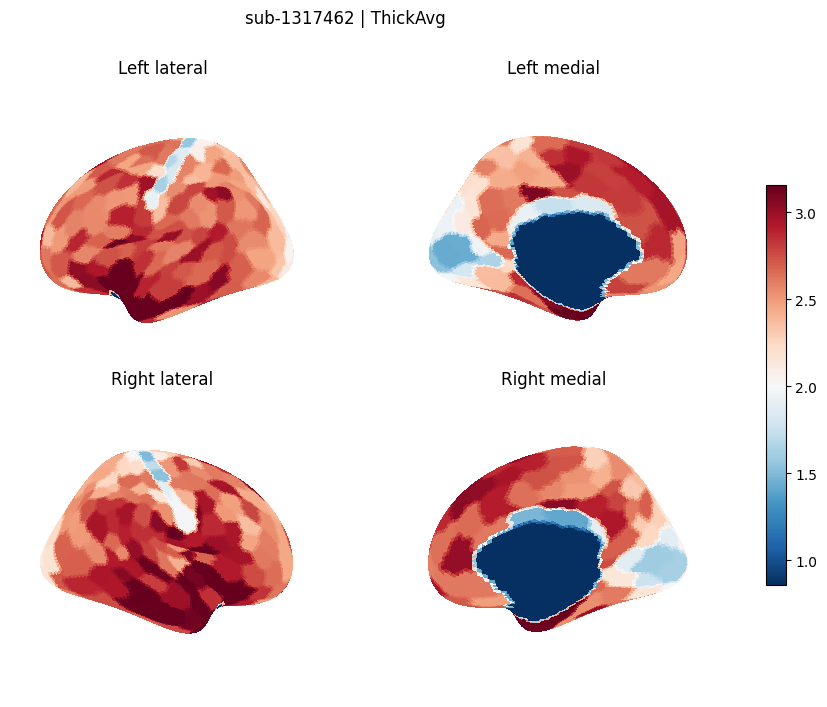

In [12]:
# Example: show cortical thickness for one demo subject.
demo_subject = subjects[0]  # Take the first selected subject as a simple example.
demo_regions = get_subject_regions(demo_subject)  # Pull just this subject's regional rows.

# Convert parcel values into left/right surface textures for thickness.
lh_tex = build_texture(demo_regions, "lh", THICKNESS_MEASURE)
rh_tex = build_texture(demo_regions, "rh", THICKNESS_MEASURE)

# Alternative compact plot with one lateral view per hemisphere.
# plot_two_hemispheres(
#     lh_tex,
#     rh_tex,
#     title=f"{demo_subject} | {THICKNESS_MEASURE}",
# )

# Main plot used in the demo: four standard views.
plot_four_views(
    lh_tex,
    rh_tex,
    title=f"{demo_subject} | {THICKNESS_MEASURE}",
)


## 6) Plot the mean cortical thickness pattern across the 100 demo subjects

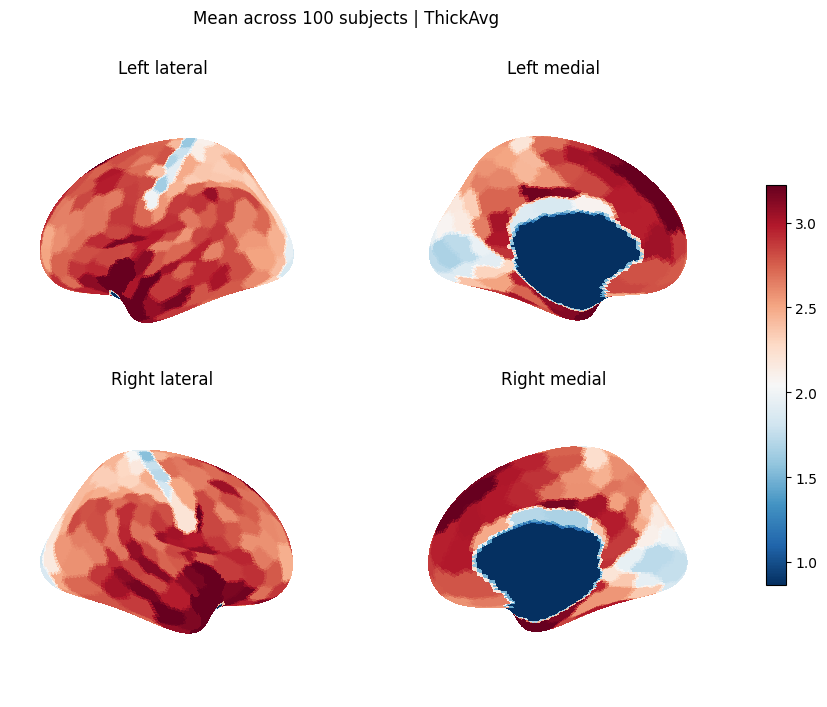

In [13]:
# Group-level example: average cortical thickness across all selected subjects.
lh_mean_tex, rh_mean_tex = build_group_mean_textures(THICKNESS_MEASURE)

# Alternative compact plot.
# plot_two_hemispheres(
#     lh_mean_tex,
#     rh_mean_tex,
#     title=f"Mean across {N_SUBJECTS} subjects | {THICKNESS_MEASURE}",
# )

# Plot the group-average thickness map in four views.
plot_four_views(
    lh_mean_tex,
    rh_mean_tex,
    title=f"Mean across {N_SUBJECTS} subjects | {THICKNESS_MEASURE}",
)


## 7) Plot gray matter volume for one subject

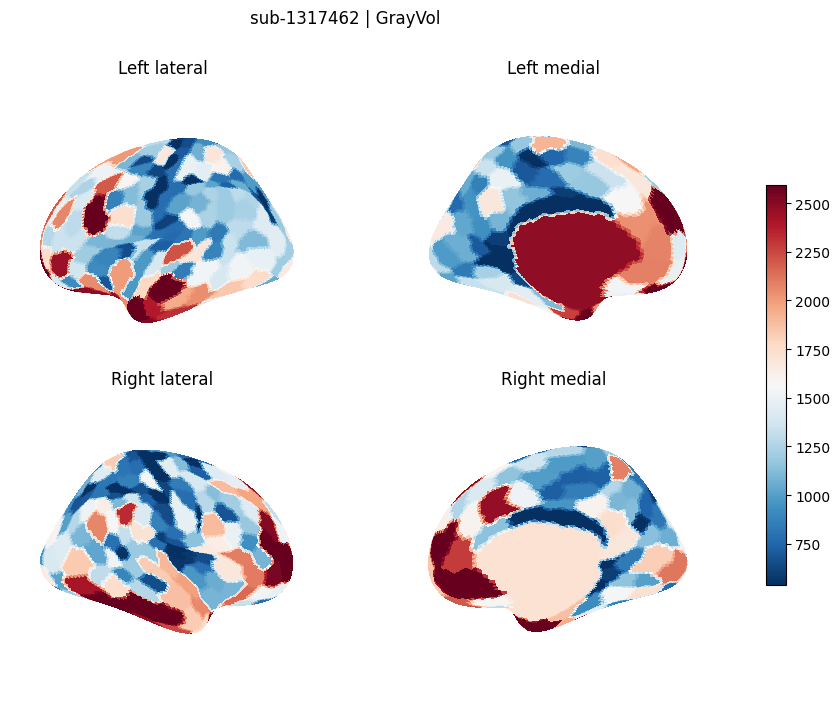

In [14]:
# Repeat the single-subject visualization, but now for gray-matter volume.
lh_tex = build_texture(demo_regions, "lh", GRAYVOL_MEASURE)
rh_tex = build_texture(demo_regions, "rh", GRAYVOL_MEASURE)

plot_four_views(
    lh_tex,
    rh_tex,
    title=f"{demo_subject} | {GRAYVOL_MEASURE}",
)


## 8) Plot the mean gray matter volume pattern across the 100 demo subjects

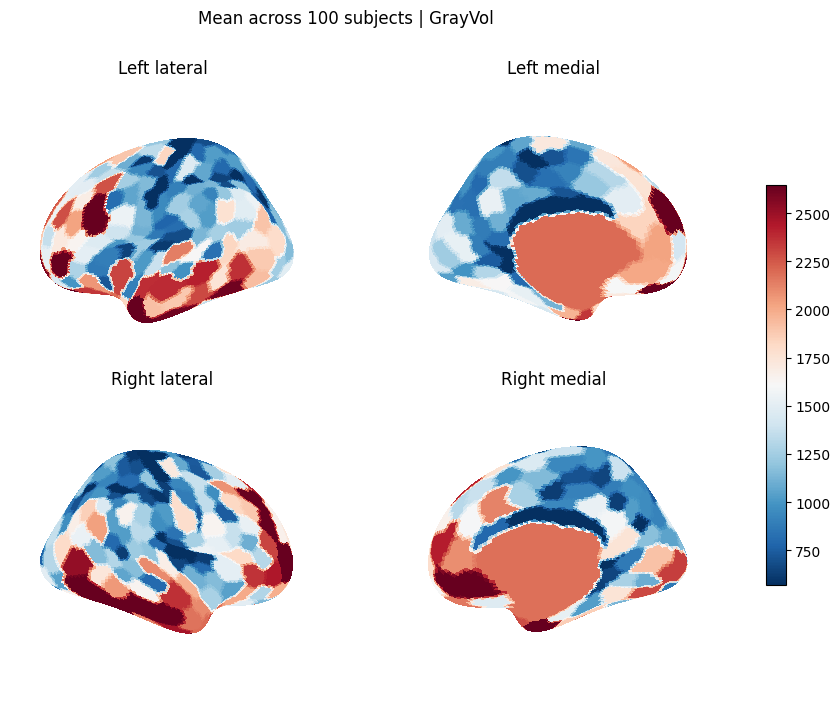

In [15]:
# Group-level gray-matter volume map across the selected subjects.
lh_mean_tex, rh_mean_tex = build_group_mean_textures(GRAYVOL_MEASURE)

plot_four_views(
    lh_mean_tex,
    rh_mean_tex,
    title=f"Mean across {N_SUBJECTS} subjects | {GRAYVOL_MEASURE}",
)


## 9) Scatter plot: mean cortical thickness vs age

Note that age-related changes in brain features are typically nonlinear. Therefore, it is better to use models that are capable of assessing both linear and nonlinear associations between brain features and age (e.g., generalized additive models or GAMs). In the simplified example below, we add a linear fit to the scatter plot to show the overall association between whole-brain mean cortical thickness and age, for visualization purposes only.

participants_df shape: (1601, 19)
Participants columns: ['participant_id', 'study', 'study_site', 'session_id', 'wave', 'age', 'sex', 'race', 'ethnicity', 'bmi', 'handedness', 'participant_education', 'parent_1_education', 'parent_2_education', 'p_factor_mcelroy_harmonized_all_samples', 'internalizing_mcelroy_harmonized_all_samples', 'externalizing_mcelroy_harmonized_all_samples', 'attention_mcelroy_harmonized_all_samples', 'cubids_acquisition_group']


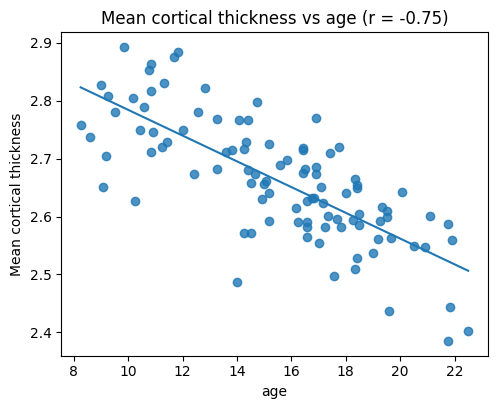

,subject_id,mean_cortical_thickness,age
0,100527940,2.758634,8.250000
1,103652366,2.654214,18.416667
2,107578676,2.827836,9.000000
3,108828000,2.674644,16.416667
4,113335479,2.715520,16.416667


In [16]:
# Whole-brain mean cortical thickness: simple average across Schaefer parcels for each subject.
# This creates one summary thickness value per participant.
thickness_by_subject = (
    regions_df.loc[regions_df["atlas"].astype(str) == ATLAS]
    .groupby("subject_id", as_index=False)[THICKNESS_MEASURE]
    .mean()
    .rename(columns={THICKNESS_MEASURE: "mean_cortical_thickness"})
)

# Load participant metadata so we can compare thickness with age.
participants_df = pd.read_csv(PARTICIPANTS_TSV_URL, sep="	")
print("participants_df shape:", participants_df.shape)
print("Participants columns:", participants_df.columns.tolist())

# Try to identify the participant ID column, even if the exact column name varies.
participant_col_candidates = [
    c for c in participants_df.columns
    if c.lower() in {"participant_id", "subject_id", "src_subject_id"}
]
if not participant_col_candidates:
    participant_col_candidates = [c for c in participants_df.columns if "participant" in c.lower() or "subject" in c.lower()]
if not participant_col_candidates:
    raise RuntimeError("Could not find a participant ID column in the PNC_BIDS participants table.")
participant_col = participant_col_candidates[0]

# Do the same for age.
age_col_candidates = [c for c in participants_df.columns if c.lower() == "age"]
if not age_col_candidates:
    age_col_candidates = [c for c in participants_df.columns if "age" in c.lower()]
if not age_col_candidates:
    raise RuntimeError("Could not find an age column in the PNC_BIDS participants table.")
age_col = age_col_candidates[0]

# Keep just subject ID and age, and standardize the subject ID format.
age_df = participants_df[[participant_col, age_col]].copy()
age_df["subject_id"] = age_df[participant_col].astype(str).str.replace("^sub-", "", regex=True)
age_df = age_df[["subject_id", age_col]].dropna()

# Merge the thickness summary with age so each row has both values.
scatter_df = thickness_by_subject.copy()
scatter_df["subject_id"] = scatter_df["subject_id"].astype(str).str.replace("^sub-", "", regex=True)
scatter_df = scatter_df.merge(age_df, on="subject_id", how="inner").dropna()

# Convert to numeric arrays and remove any non-finite values before plotting.
x = pd.to_numeric(scatter_df[age_col], errors="coerce").to_numpy()
y = pd.to_numeric(scatter_df["mean_cortical_thickness"], errors="coerce").to_numpy()
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Make a scatter plot and add a simple best-fit line.
plt.figure(figsize=(5.5, 4.2))
plt.scatter(x, y, alpha=0.8)
m, b = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, m * xx + b)

# Compute and display the correlation coefficient in the title.
corr = np.corrcoef(x, y)[0, 1]
plt.xlabel(age_col)
plt.ylabel("Mean cortical thickness")
plt.title(f"Mean cortical thickness vs age (r = {corr:.2f})")
plt.show()

# Preview the merged table used for the scatter plot.
scatter_df.head()


## 10) Quick summary tables

In [17]:
# Preview the pass-QC participant table used to choose subjects for the demo.
qc_pass.head(N_SUBJECTS)


,participant_id,study,session_id,euler,rater_1,rater_3,rater_4,rater_5,rater_6,across_rater_average,qc_determination
0,1317462,PNC,PNC-1,-64,1.0,1.0,NaN,NaN,NaN,1.0,Pass
1,8454119,PNC,PNC-1,-145,NaN,1.0,1.0,NaN,1.0,1.0,Pass
2,11407866,PNC,PNC-1,-95,1.0,NaN,NaN,1.0,NaN,1.0,Pass
3,11574123,PNC,PNC-1,-91,1.0,NaN,NaN,1.0,NaN,1.0,Pass
4,16684978,PNC,PNC-1,-95,NaN,1.0,1.0,NaN,1.0,1.0,Pass
...,...,...,...,...,...,...,...,...,...,...,...
95,307169010,PNC,PNC-1,-122,1.0,1.0,1.0,1.0,1.0,1.0,Pass
96,307804547,PNC,PNC-1,-161,1.0,NaN,NaN,1.0,NaN,1.0,Pass
97,308228517,PNC,PNC-1,-52,NaN,1.0,1.0,NaN,1.0,1.0,Pass
98,309129555,PNC,PNC-1,-147,NaN,NaN,1.0,1.0,1.0,1.0,Pass


In [18]:
# Preview the whole-brain summary table assembled from the per-subject files.
brain_df.head()


,subject_id,session_id,lh_euler,rh_euler,lh_holes,rh_holes,Cortex_NumVert_lh,Cortex_PialSurfArea_lh,Cortex_MeanThickness_lh,BrainSeg_BrainSegVol_lh,...,SubCortGray_SubCortGrayVol,TotalGray_TotalGrayVol,SupraTentorial_SupraTentorialVol,SupraTentorialNotVent_SupraTentorialVolNotVent,SupraTentorialNotVentVox_SupraTentorialVolNotVentVox,Mask_MaskVol,lhSurfaceHoles,rhSurfaceHoles,SurfaceHoles,EstimatedTotalIntraCranialVol_eTIV
0,sub-1317462,NaN,-70.0,-58.0,36.0,30.0,140162.0,109462.0,2.56670,1228211.0,...,60819.0,676981.029232,1.110285e+06,1.103679e+06,1100483.0,1488216.0,36.0,30.0,66.0,1.503734e+06
1,sub-8454119,NaN,-136.0,-154.0,69.0,78.0,165571.0,130175.0,2.70332,1349721.0,...,62088.0,841221.734961,1.198286e+06,1.191895e+06,1189357.0,1597085.0,69.0,78.0,147.0,1.627830e+06
2,sub-11407866,NaN,-100.0,-90.0,51.0,46.0,139186.0,115997.0,2.89178,1302289.0,...,61227.0,781357.043619,1.162905e+06,1.149642e+06,1147073.0,1542626.0,51.0,46.0,97.0,1.636617e+06
3,sub-11574123,NaN,-110.0,-72.0,56.0,37.0,132015.0,106776.0,2.70228,1180390.0,...,57612.0,705171.787662,1.039609e+06,1.031240e+06,1028936.0,1432895.0,56.0,37.0,93.0,1.547183e+06
4,sub-16684978,NaN,-100.0,-90.0,51.0,46.0,113041.0,90776.2,2.56145,990771.0,...,47515.0,589074.498125,8.503083e+05,8.457273e+05,843294.0,1208001.0,51.0,46.0,97.0,1.300315e+06
